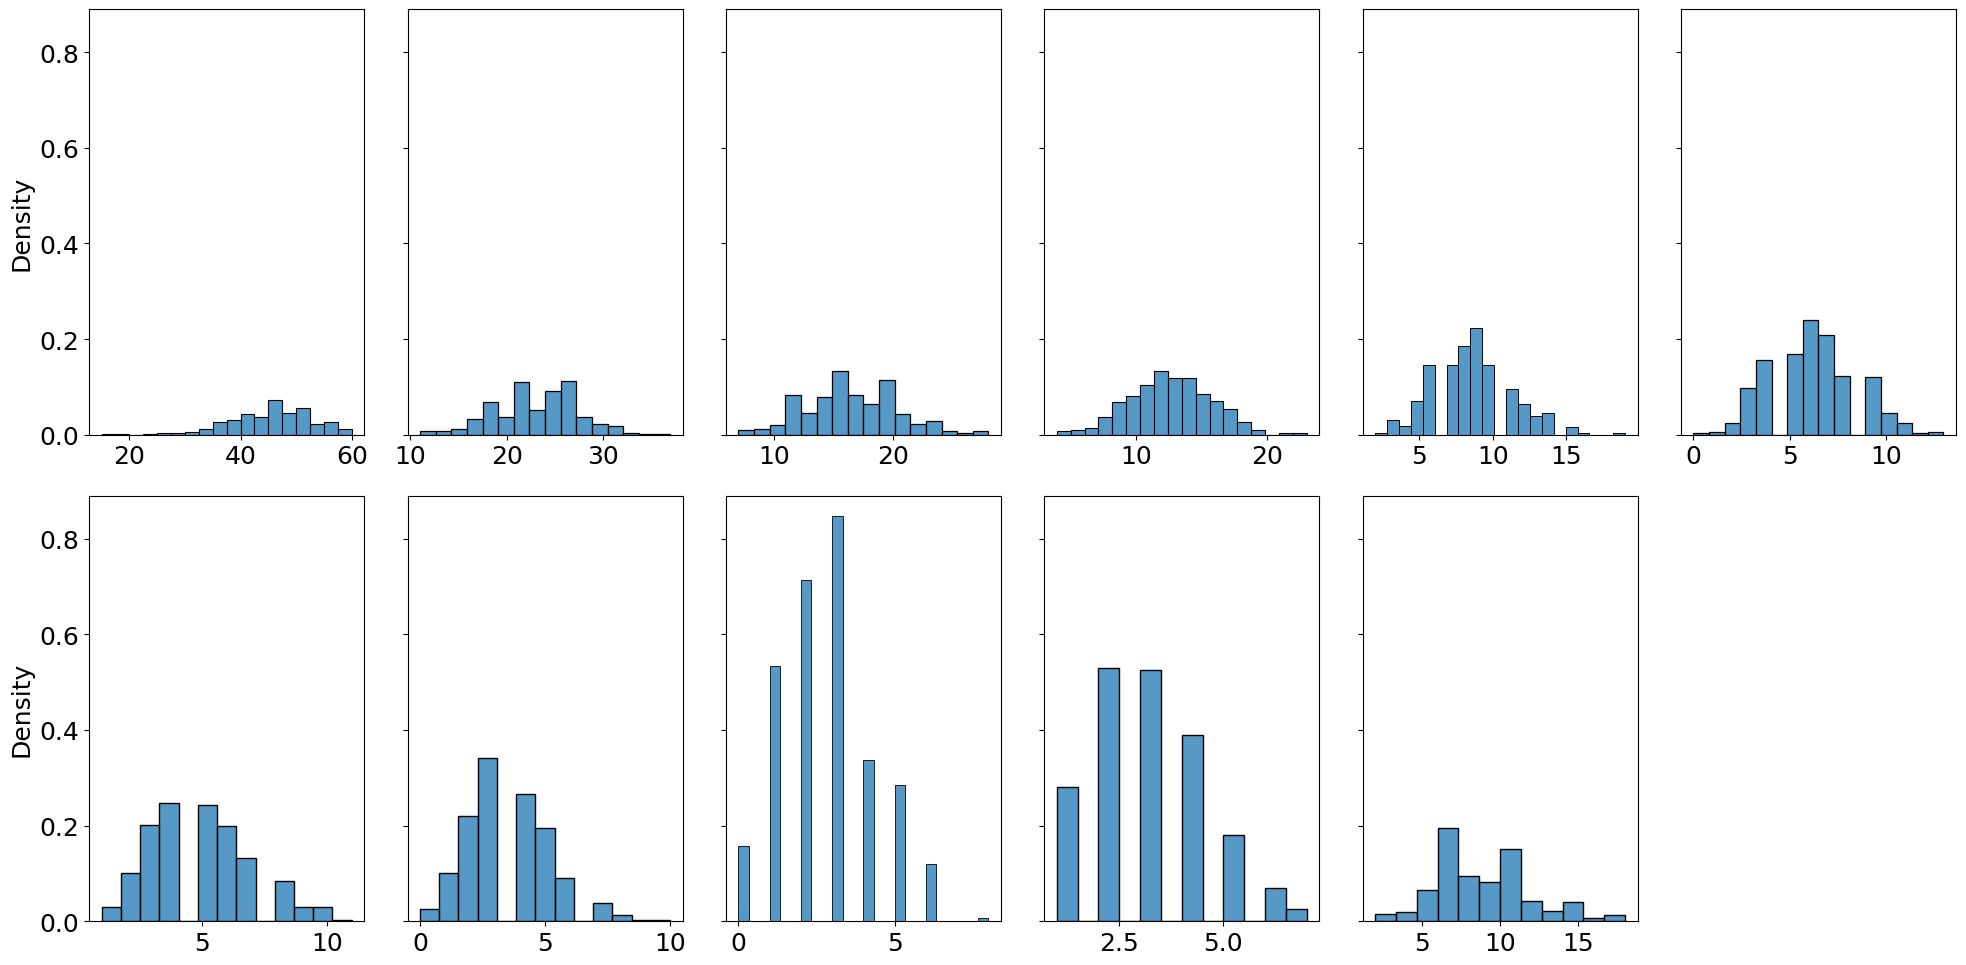

In [87]:
import GenomeRearrangement as GR
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from seaborn import histplot
import warnings
warnings.simplefilter('ignore', Warning)
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

tree_file = "../data/yeast/candida.tree"
# empiric_file = '../data/microbial/Ecoli73_genomes_tabs.txt'
# empiric_sumstats = GR.genomes(empiric_file, tree_file).get_sum_stats()

r = np.zeros(shape=(400,11))
for i in range(len(r)):
    simulator = GR.Sim(tree_file)

    sim_params = {
    "Chromosomes": [4,10,18],
    "AParam": 1.11,
    "maxBlockSize": 20,
    "InvertionRate": 0.039,
    "TranslocateRatio": 0.17,
    "FusionRate": 0.0545,
    "FissionRate": 0.0057,
    "DuplicationRate": 0.1,
    "LossRate":  0.01,
    "randRootAparam":  1.1
    }
    sim_params = list(sim_params.values())

    simulator.init_sim(*sim_params)

    simulated_genomes = simulator.run_sim()

    genomes_object = GR.genomes(simulated_genomes, simulator.get_tree())
    sumarry_statistics = genomes_object.get_sum_stats()
    r[i] = np.array(sumarry_statistics[0])

t = len(r[0])//2+1
change_font(18)
fig, ax = plt.subplots(2,t, tight_layout=True, figsize=(20,10), sharey=True)
for i in range(len(r[0])):
    axx = ax[i//t,i%t]
    histplot(r[:,i], ax = axx, stat='density')
ax[-1,-1].set_axis_off()

In [50]:
from sbi.inference import MCABC
import torch
from sbi.utils import BoxUniform
from sbi.inference import simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.simplefilter('ignore', Warning)


In [91]:
# Define Prior for ABC
prior = BoxUniform(low=torch.tensor([1.001,0,0,0,0]), high=torch.tensor([2,1.5,1.5,0.8,0.03]))
# Simulator and empirical data

def simulator(params):
    simulator = GR.Sim(tree_file)
    chrs = [4,10,18]
    sim_params = {
    "Chromosomes": chrs,
    "AParam": params[0].item(),
    "maxBlockSize": 20,
    "InvertionRate": params[1].item(),
    "TranslocateRatio": params[2].item(),
    "FusionRate": params[3].item(),
    "FissionRate": params[4].item(),
    "DuplicationRate": 0.1,
    "LossRate":  0.01,
    "randRootAparam":  1.1
    }
    sim_params = list(sim_params.values())
    
    simulator.init_sim(*sim_params)
    simulated_genomes = simulator.run_sim()
    genomes_object = GR.genomes(simulated_genomes, simulator.get_tree())
    sumarry_statistics = genomes_object.get_sum_stats()
    return sumarry_statistics[0]

prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
X = r[42:52]
log_probs = []
abcs = []

# Quick inference with ABC
# Distance threshold is high because our data is very noisy
for i in range(len(X)):
    x = X[i,:]
    abc = MCABC(prior=prior, simulator=simulator)
    y = abc(x_o=x, num_simulations=10000, kde=True, quantile=0.005)
    log_probs.append(y.log_prob)
    abcs.append(y)

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

In [93]:
import sys
sys.path.insert(1,'../../../collective_posterior')
from collective_posterior import CollectivePosterior
true_params = torch.tensor([1.11,0.039,0.17,0.0545,0.0057])
Xs = torch.tensor(X)
cp = CollectivePosterior(prior, Xs, posterior_list=log_probs, epsilon=-10000)
print(cp.get_log_C(n_reps=1))
samples = cp.sample(50)
est = samples.mean(0)
print(cp.log_prob(est.reshape(1,-1)))
print(cp.log_prob(true_params.reshape(1,-1)))

tensor(671.7756)


Rejection Sampling: 100%|██████████| 50/50 [02:19<00:00,  2.80s/it]

tensor([-1161.7753])
tensor([-806.8412])


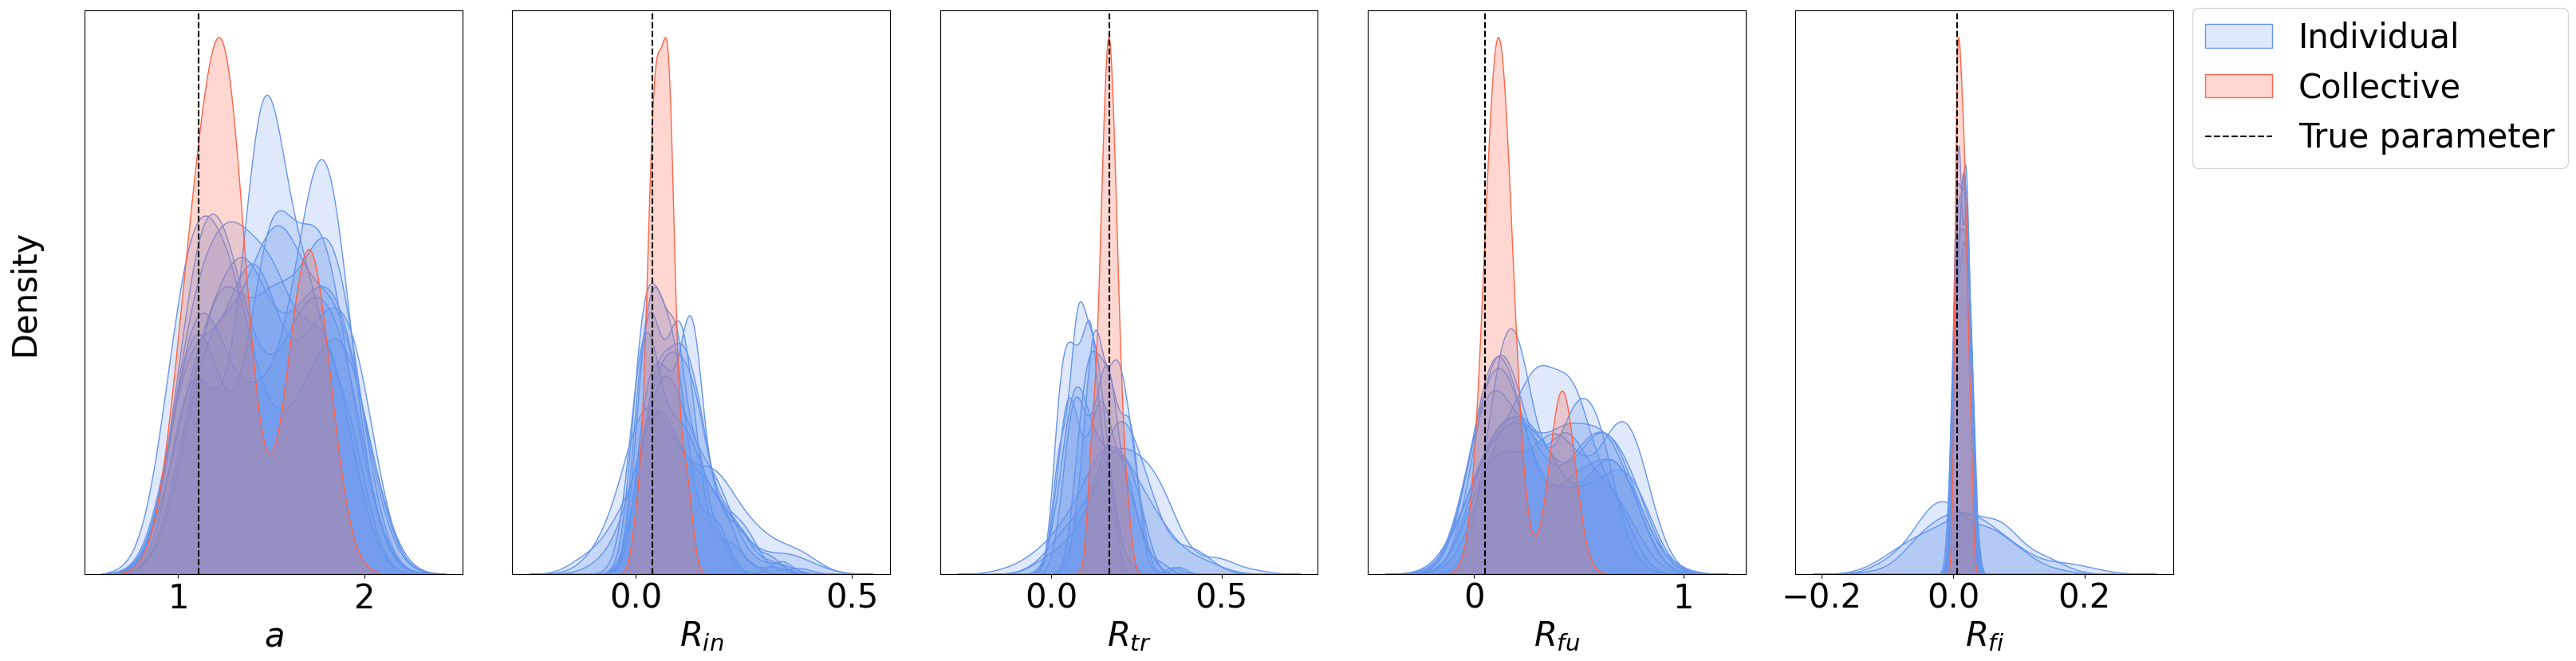

In [103]:
from seaborn import kdeplot
import matplotlib
fig, ax = plt.subplots(1,5,figsize=(33,9), tight_layout=True)
# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

change_font(30)
for j in range(5):
    for i in range(len(abcs)):
        samples_ind = abcs[i].sample((100,))[:,j]
        kdeplot(samples_ind, ax=ax[j], color='cornflowerblue', fill=True, alpha=0.2, label = 'Individual' if i==0 else '')
    kdeplot(samples[:,j], ax=ax[j], color='tomato', fill=True, label = 'Collective')
    ax[j].axvline(true_params[j], color='k', label = 'True parameter', ls='--')
    ax[j].set_ylabel('')
ax[4].legend(loc = (1.05,0.72))
ax[0].set_ylabel('Density\n')
ax[0].set_xlabel('$a$')
ax[1].set_xlabel('$R_{in}$')
ax[2].set_xlabel('$R_{tr}$')
ax[3].set_xlabel('$R_{fu}$')
ax[4].set_xlabel('$R_{fi}$')
for i in range(5):
    ax[i].set_yticks([])